In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("../datasets/netflix.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,14-Aug-20,2020,TV-MA,4,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s10,Movie,1920,Vikram Bhatt,"Rajneesh Duggal, Adah Sharma, Indraneil Sengup...",India,15-Dec-17,2008,TV-MA,143,"Horror Movies, International Movies, Thrillers",An architect and his wife move into a castle t...
2,s100,Movie,3 Heroines,Iman Brotoseno,"Reza Rahadian, Bunga Citra Lestari, Tara Basro...",Indonesia,5-Jan-19,2016,TV-PG,124,"Dramas, International Movies, Sports Movies",Three Indonesian women break records by becomi...
3,s1000,Movie,Blue Mountain State: The Rise of Thadland,Lev L. Spiro,"Alan Ritchson, Darin Brooks, James Cade, Rob R...",United States,1-Mar-16,2016,R,90,Comedies,New NFL star Thad buys his old teammates' belo...
4,s1001,TV Show,Blue Planet II,NaN,David Attenborough,United Kingdom,3-Dec-18,2017,TV-G,1,"British TV Shows, Docuseries, Science & Nature TV",This sequel to the award-winning nature series...


In [3]:
df.shape

(7787, 12)

# Data Cleaning and Transformation

## Handling Null Values

In [4]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2389
cast             718
country          507
date_added        10
release_year       0
rating             7
duration           0
genres             0
description        0
dtype: int64

In [5]:
df[['date_added', 'country', 'cast', 'director','rating']] = (
    df[['date_added', 'country', 'cast', 'director','rating']]
    .fillna('Unknown')
)

In [6]:
df.duplicated().sum()


np.int64(0)

In [7]:
df['type'] = df['type'].str.strip()
df['country'] = df['country'].str.strip()

In [8]:
df.dtypes

show_id           str
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration        int64
genres            str
description       str
dtype: object

In [9]:
df['show_id_num'] = df['show_id'].str.replace('s', '').astype(int)
df.sort_values('show_id_num')
df['show_id_num']

0          1
1         10
2        100
3       1000
4       1001
        ... 
7782     995
7783     996
7784     997
7785     998
7786     999
Name: show_id_num, Length: 7787, dtype: int64

## Exploratory Data Analysis

In [10]:
df['type'].value_counts()

type
Movie      5377
TV Show    2410
Name: count, dtype: int64

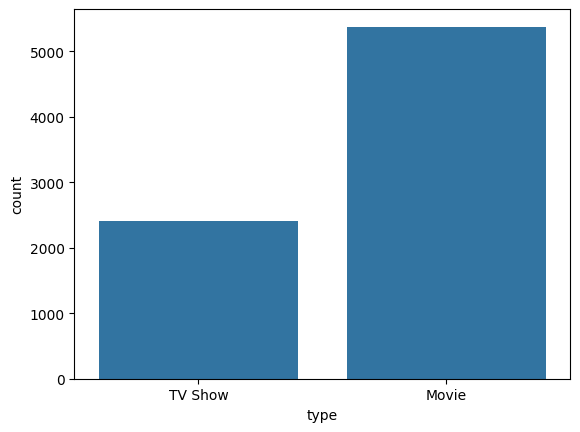

In [11]:
sns.countplot(data=df,x='type')
plt.show()

In [12]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year

C:\Users\91767\AppData\Local\Temp\ipykernel_16920\1638817607.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')


In [13]:
df.groupby('year_added')['show_id'].count()

year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      11
2014.0      25
2015.0      88
2016.0     443
2017.0    1225
2018.0    1685
2019.0    2153
2020.0    2009
2021.0     117
Name: show_id, dtype: int64

### Content Added by over time

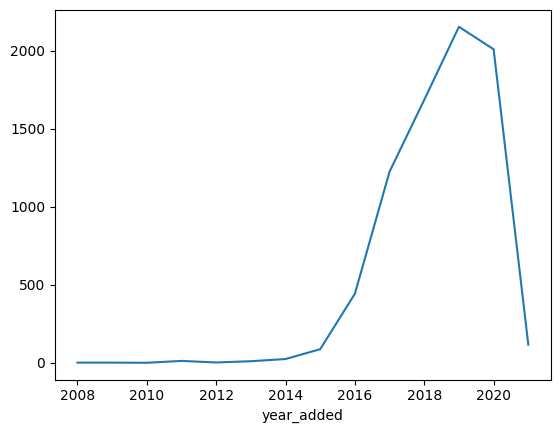

In [14]:
df.groupby('year_added')['show_id'].count().plot()
plt.show()

### Content by Top Countries

In [15]:
df['country'].value_counts().head(5)

country
United States     2555
India              923
Unknown            507
United Kingdom     397
Japan              226
Name: count, dtype: int64

### common ratings

In [16]:
df['rating'].value_counts()

rating
TV-MA       2863
TV-14       1931
TV-PG        806
R            665
PG-13        386
TV-Y         280
TV-Y7        271
PG           247
TV-G         194
NR            84
G             39
Unknown        7
TV-Y7-FV       6
UR             5
NC-17          3
Name: count, dtype: int64

### Genres Categorization

In [17]:
df['genres'].value_counts().head(10)

genres
Documentaries                                       334
Stand-Up Comedy                                     321
Dramas, International Movies                        320
Comedies, Dramas, International Movies              243
Dramas, Independent Movies, International Movies    215
Kids' TV                                            205
Children & Family Movies                            177
Documentaries, International Movies                 172
Children & Family Movies, Comedies                  169
Comedies, International Movies                      161
Name: count, dtype: int64

In [18]:
df[['type', 'duration']].head(20)

,type,duration
0,TV Show,4
1,Movie,143
2,Movie,124
3,Movie,90
4,TV Show,1
5,Movie,90
6,Movie,94
7,Movie,112
8,Movie,129
9,Movie,85


In [19]:
df['duration_unit'] = df['type'].map({
    'Movie': 'min',
    'TV Show': 'Season'
})
df['duration_unit'].head()
df['duration_unit'].value_counts()
pd.crosstab(df['type'], df['duration_unit'])

duration_unit,Season,min
type,,
Movie,0,5377
TV Show,2410,0


## Exporting the cleaned File

In [20]:
df.to_csv(
    "../cleaned_data/netflix_cleaned.csv",
    index=False
)